In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
from scipy.sparse import issparse
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

print("Import thư viện thành công!")

Import thư viện thành công!


LOAD DỮ LIỆU

In [11]:
# NAIVE BAYES — Load từ .pkl (đã vectorize sẵn)
print('[Naive Bayes] Load từ .pkl...')

X_train_nb   = joblib.load('../../../DATA/DATA_PREPROCESSING/EMAIL/PKL/X_train_balance.pkl')
X_test_nb    = joblib.load('../../../DATA/DATA_PREPROCESSING/EMAIL/PKL/X_test_balance.pkl')
y_train_nb   = np.asarray(joblib.load('../../../DATA/DATA_PREPROCESSING/EMAIL/PKL/y_train_balance.pkl')).astype(int)
y_test_nb    = np.asarray(joblib.load('../../../DATA/DATA_PREPROCESSING/EMAIL/PKL/y_test_balance.pkl')).astype(int)

print(f'   X_train_nb : {X_train_nb.shape}')
print(f'   X_test_nb  : {X_test_nb.shape}')
print(f'   y_train_nb — Spam: {y_train_nb.sum()} | Ham: {len(y_train_nb) - y_train_nb.sum()}')
print(f'   y_test_nb  — Spam: {y_test_nb.sum()} | Ham: {len(y_test_nb) - y_test_nb.sum()}')


# SVM — Load từ .csv + TF-IDF sklearn (max_features=1500, bigram, sublinear_tf)
print('\n[SVM] Load từ CSV + TF-IDF...')

train_df    = pd.read_csv('../../../DATA/DATA_PREPROCESSING/EMAIL/CSV/train_balance.csv')
test_df     = pd.read_csv('../../../DATA/DATA_PREPROCESSING/EMAIL/CSV/test_balance.csv')

X_train_raw = train_df['text'].values
X_test_raw  = test_df['text'].values
y_train_svm = np.array(train_df['spam'].values).astype(int)
y_test_svm  = np.array(test_df['spam'].values).astype(int)

# Tham số TF-IDF giữ nguyên từ SVM notebook
tfidf = TfidfVectorizer(
    max_features=10000,
    sublinear_tf=True,
    token_pattern=r'\b\w{2,}\b',
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)
X_train_svm = tfidf.fit_transform(X_train_raw)
X_test_svm  = tfidf.transform(X_test_raw)

print(f'   X_train_svm: {X_train_svm.shape}')
print(f'   X_test_svm : {X_test_svm.shape}')
print(f'   y_train_svm — Spam: {y_train_svm.sum()} | Ham: {len(y_train_svm) - y_train_svm.sum()}')
print(f'   y_test_svm  — Spam: {y_test_svm.sum()} | Ham: {len(y_test_svm) - y_test_svm.sum()}')

print('\nLoad dữ liệu NB + SVM hoàn tất!')

[Naive Bayes] Load từ .pkl...
   X_train_nb : (6552, 10000)
   X_test_nb  : (1639, 10000)
   y_train_nb — Spam: 3249 | Ham: 3303
   y_test_nb  — Spam: 813 | Ham: 826

[SVM] Load từ CSV + TF-IDF...
   X_train_svm: (6552, 10000)
   X_test_svm : (1639, 10000)
   y_train_svm — Spam: 3249 | Ham: 3303
   y_test_svm  — Spam: 813 | Ham: 826

Load dữ liệu NB + SVM hoàn tất!


ĐỊNH NGHĨA CÁC MÔ HÌNH

In [12]:
# MÔ HÌNH 1: MULTINOMIAL NAIVE BAYES (From Scratch)
class MultinomialNaiveBayesFromScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None

    def fit(self, X, y):
        y = np.asarray(y).astype(int)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        self.class_log_prior_ = np.zeros(len(self.classes_))
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features))
        for i, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.class_log_prior_[i] = np.log(X_c.shape[0] / n_samples)
            feature_count = np.asarray(X_c.sum(axis=0)).ravel()
            smoothed_count = feature_count + self.alpha
            self.feature_log_prob_[i] = np.log(smoothed_count / smoothed_count.sum())
        return self

    def predict_log_proba(self, X):
        joint = X.dot(self.feature_log_prob_.T) + self.class_log_prior_
        joint = np.asarray(joint)
        max_log = np.max(joint, axis=1, keepdims=True)
        log_sum = max_log + np.log(np.sum(np.exp(joint - max_log), axis=1, keepdims=True))
        return joint - log_sum

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]


# MÔ HÌNH 2: SVM - SUPPORT VECTOR MACHINE (From Scratch)
class SVMFromScratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_transformed = np.where(y <= 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0
        for epoch in range(self.n_iters):
            for idx in range(n_samples):
                x_i = X[idx]
                decision = np.asarray(x_i.dot(self.w)).ravel()[0] + self.b
                if y_transformed[idx] * decision >= 1:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                else:
                    x_i_dense = x_i.toarray().ravel() if issparse(x_i) else x_i
                    self.w -= self.learning_rate * (
                        2 * self.lambda_param * self.w - x_i_dense * y_transformed[idx]
                    )
                    self.b += self.learning_rate * y_transformed[idx]
            if (epoch + 1) % 1 == 0:
                print(f'   Epoch {epoch+1}/{self.n_iters} hoàn tất')
        return self

    def predict(self, X):
        linear_output = np.asarray(X.dot(self.w)).ravel() + self.b
        return np.where(np.sign(linear_output) > 0, 1, 0)


# MÔ HÌNH 3: LOGISTIC REGRESSION (From Scratch)
class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.5, max_iter=10000, lambda_=0.01, threshold=0.27):
        self.learning_rate = learning_rate
        self.max_iter      = max_iter
        self.lambda_       = lambda_
        self.threshold     = threshold
        self.weights       = None
        self.bias          = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def _compute_loss(self, y_true, y_pred):
        m        = len(y_true)
        loss     = (-1/m) * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
        reg_loss = (self.lambda_ / (2 * m)) * np.sum(self.weights ** 2)
        return loss + reg_loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0
        print(f"  Huấn luyện Logistic Regression ({n_samples} mẫu, {n_features} features)...")
        for i in range(self.max_iter):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred        = self._sigmoid(linear_output)
            # Gradient với L2 regularization — giống hệt logistic_regression.py
            dw  = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            dw += (self.lambda_ / n_samples) * self.weights
            db  = (1 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db
            if i % 1000 == 0:
                loss = self._compute_loss(y, y_pred)
                print(f"    Iter {i}/{self.max_iter} | Loss: {loss:.4f}")
        print("  Huấn luyện Logistic Regression thành công!")
        return self

    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.weights) + self.bias)

    def predict(self, X, threshold=None):
        thr = threshold if threshold is not None else self.threshold
        return (self.predict_proba(X) >= thr).astype(int)

print("Đã định nghĩa xong các class mô hình!")

Đã định nghĩa xong các class mô hình!


LOAD DỮ LIỆU - LOGISTIC REGRESSION

In [13]:
# LOGISTIC REGRESSION — Load trực tiếp từ spam_model.pkl (không cần train lại)
print('[Logistic Regression] Load model từ spam_model.pkl...')

lr_bundle      = joblib.load('../../LOGISTIC REGRESSION/spam_balance_model.pkl')
lr_vectorizer  = lr_bundle['vectorizer']   # sklearn TfidfVectorizer đã fit sẵn
lr_weights     = lr_bundle['weights']      # ndarray shape (vocab,)
lr_bias        = lr_bundle['bias']         # float
lr_threshold   = 0.63  # float, mặc định 0.45

print(f'   Vocab size   : {len(lr_weights)}')
print(f'   Bias         : {lr_bias:.6f}')
print(f'   Threshold    : {lr_threshold}')

# Vectorize test set bằng vectorizer đã fit sẵn trong pkl
# (dùng lại X_test_raw / y_test_svm từ cell Load dữ liệu phía trên)
y_test_lr  = y_test_svm.copy()   # cùng test set
X_test_lr  = lr_vectorizer.transform(X_test_raw)   # sparse matrix

print(f'   X_test_lr  : {X_test_lr.shape}')
print(f'   y_test_lr  — Spam: {y_test_lr.sum()} | Ham: {len(y_test_lr) - y_test_lr.sum()}')
print('\nLoad Logistic Regression từ pkl hoàn tất!')


[Logistic Regression] Load model từ spam_model.pkl...
   Vocab size   : 53244
   Bias         : 0.969001
   Threshold    : 0.63
   X_test_lr  : (1639, 53244)
   y_test_lr  — Spam: 813 | Ham: 826

Load Logistic Regression từ pkl hoàn tất!


TÍNH METRICS & VẼ CONFUSION MATRIX

In [14]:
def compute_metrics(y_true, y_pred):
    """Tính Accuracy, Precision, Recall, F1, FPR, Specificity, MCC từ gốc."""
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))

    total       = TP + TN + FP + FN
    accuracy    = (TP + TN) / total if total else 0
    precision   = TP / (TP + FP)   if (TP + FP) else 0
    recall      = TP / (TP + FN)   if (TP + FN) else 0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    fpr         = FP / (TN + FP)   if (TN + FP) else 0

    return {
        'Accuracy': accuracy, 'Precision': precision,
        'Recall': recall,     'F1-Score': f1,
        'FPR': fpr,
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN
    }


def plot_confusion_matrix(ax, metrics, model_name, cmap='Blues'):
    """Vẽ confusion matrix trực quan trên một Axes."""
    cm     = np.array([[metrics['TN'], metrics['FP']],
                       [metrics['FN'], metrics['TP']]])
    total  = cm.sum()
    thresh = cm.max() / 2.0

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > thresh else 'black'
            pct   = cm[i, j] / total * 100
            ax.text(j, i, f"{cell_labels[i][j]}\n{cm[i,j]:,}\n({pct:.1f}%)",
                    ha='center', va='center', color=color, fontsize=10, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Ham (0)', 'Predicted Spam (1)'], fontsize=9)
    ax.set_yticklabels(['Actual Ham (0)', 'Actual Spam (1)'], fontsize=9)
    ax.set_xlabel('Dự đoán', fontsize=10, labelpad=8)
    ax.set_ylabel('Thực tế', fontsize=10, labelpad=8)
    ax.set_title(f'{model_name}\nAccuracy: {metrics["Accuracy"]*100:.2f}%',
                 fontsize=11, fontweight='bold', pad=12)


print('Đã định nghĩa hàm tiện ích!')

Đã định nghĩa hàm tiện ích!


HUẤN LUYỆN VÀ DỰ ĐOÁN

In [19]:
all_results = {}

# MÔ HÌNH 1: NAIVE BAYES
print('[1/3] Naive Bayes...')
nb_model  = MultinomialNaiveBayesFromScratch(alpha=0.1)
nb_model.fit(X_train_nb, y_train_nb)
y_pred_nb = nb_model.predict(X_test_nb)
all_results['Naive Bayes'] = compute_metrics(y_test_nb, y_pred_nb)
print(f'Accuracy: {all_results["Naive Bayes"]["Accuracy"]*100:.2f}%\n')

# MÔ HÌNH 2: SVM
print('[2/3] SVM...')
svm_model  = SVMFromScratch(learning_rate=0.05, lambda_param=0.0001, n_iters=70)
svm_model.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_model.predict(X_test_svm)
all_results['SVM'] = compute_metrics(y_test_svm, y_pred_svm)
print(f'Accuracy: {all_results["SVM"]["Accuracy"]*100:.2f}%\n')

# MÔ HÌNH 3: LOGISTIC REGRESSION — Dùng weights từ spam_model.pkl (không train lại)
print('[3/3] Logistic Regression (từ spam_model.pkl)...')

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

# X_test_lr là sparse matrix nên dùng .dot() hoặc @ operator
z_lr      = X_test_lr.dot(lr_weights) + lr_bias
proba_lr  = sigmoid(z_lr)
y_pred_lr = (proba_lr >= lr_threshold).astype(int)

all_results['Logistic Regression'] = compute_metrics(y_test_lr, y_pred_lr)
print(f'Accuracy: {all_results["Logistic Regression"]["Accuracy"]*100:.2f}%\n')

print('Hoàn tất! (LR không cần train lại — load từ pkl)')

[1/3] Naive Bayes...
Accuracy: 98.66%

[2/3] SVM...
   Epoch 1/70 hoàn tất
   Epoch 2/70 hoàn tất
   Epoch 3/70 hoàn tất
   Epoch 4/70 hoàn tất
   Epoch 5/70 hoàn tất
   Epoch 6/70 hoàn tất
   Epoch 7/70 hoàn tất
   Epoch 8/70 hoàn tất
   Epoch 9/70 hoàn tất
   Epoch 10/70 hoàn tất
   Epoch 11/70 hoàn tất
   Epoch 12/70 hoàn tất
   Epoch 13/70 hoàn tất
   Epoch 14/70 hoàn tất
   Epoch 15/70 hoàn tất
   Epoch 16/70 hoàn tất
   Epoch 17/70 hoàn tất
   Epoch 18/70 hoàn tất
   Epoch 19/70 hoàn tất
   Epoch 20/70 hoàn tất
   Epoch 21/70 hoàn tất
   Epoch 22/70 hoàn tất
   Epoch 23/70 hoàn tất
   Epoch 24/70 hoàn tất
   Epoch 25/70 hoàn tất
   Epoch 26/70 hoàn tất
   Epoch 27/70 hoàn tất
   Epoch 28/70 hoàn tất
   Epoch 29/70 hoàn tất
   Epoch 30/70 hoàn tất
   Epoch 31/70 hoàn tất
   Epoch 32/70 hoàn tất
   Epoch 33/70 hoàn tất
   Epoch 34/70 hoàn tất
   Epoch 35/70 hoàn tất
   Epoch 36/70 hoàn tất
   Epoch 37/70 hoàn tất
   Epoch 38/70 hoàn tất
   Epoch 39/70 hoàn tất
   Epoch 40/70 hoàn t

VISUALIZE CONFUSION MATRIX

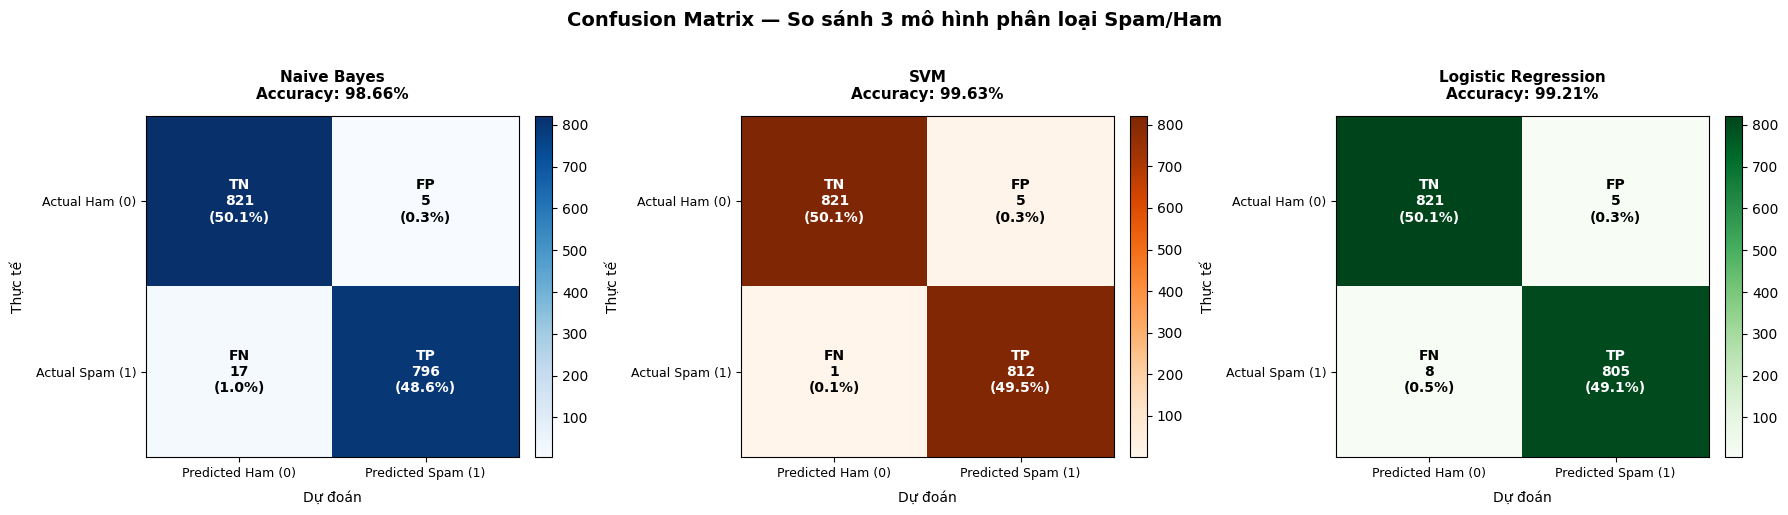

Đã lưu → 'confusion_matrices.png'


In [20]:
model_names = ['Naive Bayes', 'SVM', 'Logistic Regression']
cmaps       = ['Blues', 'Oranges', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — So sánh 3 mô hình phân loại Spam/Ham',
             fontsize=14, fontweight='bold', y=1.02)

for ax, name, cmap in zip(axes, model_names, cmaps):
    result = all_results[name]
    if result.get('__placeholder__'):
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_facecolor('#f8f8f8')
        ax.text(0.5, 0.55, name, ha='center', va='center',
                fontsize=13, fontweight='bold', color='#555')
        ax.text(0.5, 0.38, ' Chưa có source code\nBỏ comment Cell 3 & Cell 5\nkhi đã có',
                ha='center', va='center', fontsize=10, color='#888',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#e0e0e0', alpha=0.7))
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#ccc'); spine.set_linewidth(1.5)
        ax.set_title(f'{name}\n(Coming soon)', fontsize=11,
                     fontweight='bold', pad=12, color='#888')
    else:
        plot_confusion_matrix(ax, result, name, cmap=cmap)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu → 'confusion_matrices.png'")

BẢNG TỔNG HỢP CÁC CHỈ SỐ

In [21]:
metric_keys   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR']
metric_labels = {
    'Accuracy':    'Accuracy (Độ chính xác)',
    'Precision':   'Precision (Độ chuẩn xác Spam)',
    'Recall':      'Recall (Bắt sạch Spam)',
    'F1-Score':    'F1-Score',
    'FPR':         'FPR — False Positive Rate ↓',
}

rows = []
for key in metric_keys:
    row = {'Chỉ số': metric_labels[key]}
    for name in model_names:
        val = all_results[name].get(key)
        if val is None:
            row[name] = '—'
        else:
            row[name] = f'{val*100:.2f}%'
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Chỉ số')
print('BẢNG SO SÁNH TỔNG HỢP')
print('=' * 70)
display(df_summary)

BẢNG SO SÁNH TỔNG HỢP


,Naive Bayes,SVM,Logistic Regression
Chỉ số,,,
Accuracy (Độ chính xác),98.66%,99.63%,99.21%
Precision (Độ chuẩn xác Spam),99.38%,99.39%,99.38%
Recall (Bắt sạch Spam),97.91%,99.88%,99.02%
F1-Score,98.64%,99.63%,99.20%
FPR — False Positive Rate ↓,0.61%,0.61%,0.61%


BIỂU ĐỒ CỘT SO SÁNH CÁC CHỈ SỐ

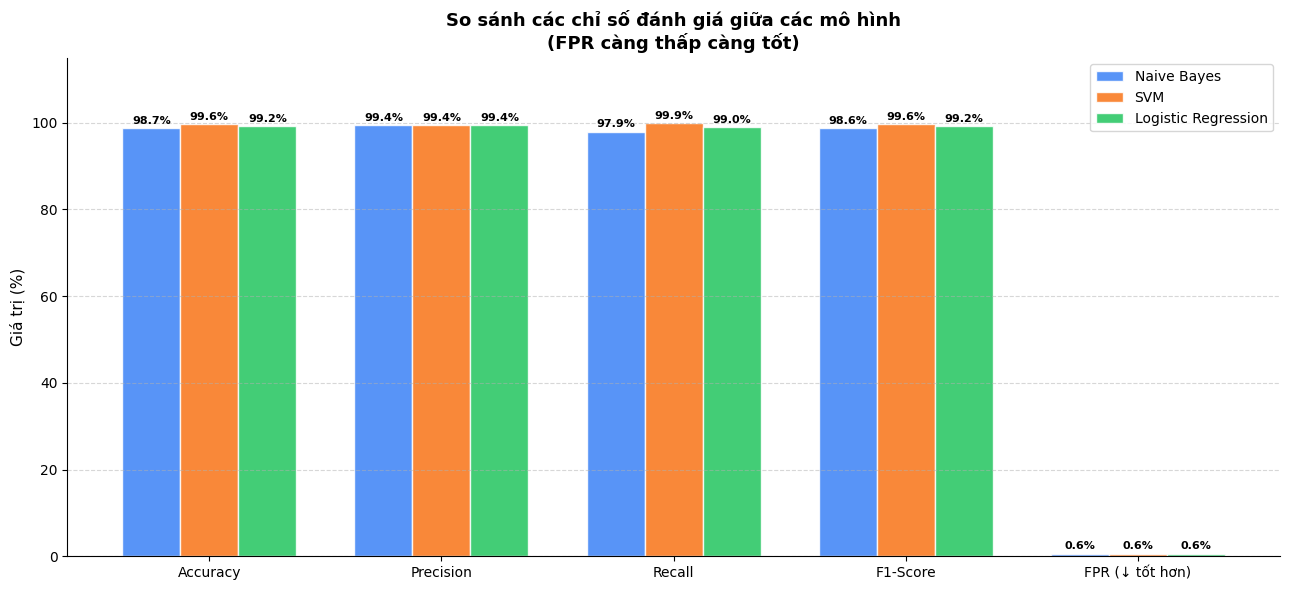

Đã lưu → 'metrics_comparison.png'


In [22]:
available    = [m for m in model_names if not all_results[m].get('__placeholder__')]
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR']
x_labels     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR (↓ tốt hơn)']
bar_colors   = ['#3b82f6', '#f97316', '#22c55e']

x     = np.arange(len(plot_metrics))
width = 0.25 if len(available) == 3 else 0.30

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(available, bar_colors)):
    vals   = [all_results[model][m] * 100 for m in plot_metrics]
    offset = (i - len(available)/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width, label=model,
                    color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Giá trị (%)', fontsize=11)
ax.set_title('So sánh các chỉ số đánh giá giữa các mô hình\n(FPR càng thấp càng tốt)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylim(0, 115)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu → 'metrics_comparison.png'")